In [26]:
import pandas as pd
import numpy as np

# 1. Read the file manually to bypass any Pandas ParserErrors
with open("newman1.blocks", "r") as f:
    lines = f.readlines()

data = []
for line in lines:
    # Split the line by any amount of whitespace
    parts = line.strip().split()

    # Skip empty lines or the standalone "1060" block count at the top
    if len(parts) <= 1:
        continue

    # Skip the text header if it exists
    if parts[0].lower() == "id":
        continue

    # If a row accidentally has 12 items (due to a stray space), force it to 11
    if len(parts) >= 11:
        data.append(parts[:11])

# 2. Build the DataFrame
minelib_columns = [
    "id", "x", "y", "z", "type", "grade", "tonns",
    "min_caf", "value_extracc", "value_proc", "apriori_process"
]
df = pd.DataFrame(data, columns=minelib_columns)

# Convert strings to numbers
for col in minelib_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Successfully cleaned and loaded {len(df)} blocks from MineLib.")

# 3. Map to your Notebook's Schema
df_mapped = pd.DataFrame()

# Match the 'B0000' style format your notebook expects
df_mapped['block_id'] = 'B' + df['id'].astype(int).astype(str).str.zfill(4)

# Spatial and physical characteristics
df_mapped['x'] = df['x']
df_mapped['y'] = df['y']
df_mapped['z'] = df['z']
df_mapped['tonnage_kt'] = df['tonns']
df_mapped['ore_grade_pct'] = df['grade']

# MineLib provides the total block value for dumping (extracc) vs milling (proc)
# The expected NPV of a block is whichever action yields the highest value.
df_mapped['npv_expected'] = np.maximum(df['value_extracc'], df['value_proc'])

# Newman1 uses `apriori_process` to designate Ore (1) vs Waste (0)
# We map this so your notebook's processing capacity constraints work.
df_mapped['ore_indicator'] = df['apriori_process']
df_mapped['waste_ratio'] = np.where(df['apriori_process'] == 1, 0.5, 2.5) # Dummy values to prevent strip_ratio errors
# Strip ratio — must match Week 4's column name exactly
df_mapped['stripping_ratio'] = np.where(df['apriori_process'] == 1, 0.5, 2.5)

# Mining cost ($/tonne) — Week 4 reads df['mining_cost_t']
# Newman1's min_caf is the mining + extraction cost in $/tonne equivalent
df_mapped['mining_cost_t'] = df['min_caf'].clip(lower=0.5).fillna(2.0)

# NPV std (Week 4 reads this for display; set to 0 since Newman1 has no uncertainty column)
df_mapped['npv_std'] = 0.0

# Slope constraint
df_mapped['slope_constraint'] = 1

# Save
df_mapped.to_csv("newman1_mapped_model.csv", index=False)
print("Columns:", df_mapped.columns.tolist())

Successfully cleaned and loaded 1060 blocks from MineLib.
Columns: ['block_id', 'x', 'y', 'z', 'tonnage_kt', 'ore_grade_pct', 'npv_expected', 'ore_indicator', 'waste_ratio', 'stripping_ratio', 'mining_cost_t', 'npv_std', 'slope_constraint']


# Week 4 — Deterministic & Multi-Objective MILP Block Scheduling

### Objectives
1. Formulate the block-sequencing MILP (binary `y[block, period]`)
2. Solve the **NPV-only** deterministic problem with PuLP / CBC
3. Build the **NPV vs Throughput** Pareto frontier via ε-constraint (Tabesh et al. 2023)
4. Add a **third objective** (strip ratio) for a genuine 3-objective analysis
5. Summarise results in a KPI table with operational interpretation

### Mathematical Foundation

Let:
- $B$ = set of blocks $\{0, \ldots, N-1\}$, $\;T$ = set of periods $\{1, \ldots, 10\}$
- $y_{b,t} \in \{0,1\}$ = 1 if block $b$ is mined in period $t$
- $\delta_t = (1+r)^{-t}$ = discount factor, $r = 10\%$
- $v_b$ = expected NPV of block $b$ (from Week 2 Monte Carlo, \$M)
- $\tau_b$ = tonnage of block $b$ (kt)
- $g_b$ = ore grade of block $b$ (fraction)
- $O_b$ = ore indicator = 1 if $g_b \geq g_{cut}$, else 0
- $\text{SR}_b$ = strip ratio of block $b$

**Objective — maximise discounted NPV:**
$$\max \; Z_{NPV} = \sum_{t=1}^{T} \delta_t \sum_{b \in B} v_b \, y_{b,t}$$

**Subject to:**

*Each block mined exactly once:*
$$\sum_{t=1}^{T} y_{b,t} = 1 \quad \forall b \in B$$

*Mining-capacity bounds (kt):*
$$\underline{MC} \leq \sum_{b} \tau_b \, y_{b,t} \leq \overline{MC} \quad \forall t$$

*Processing-capacity bounds — ore throughput per period (kt ore):*
$$\underline{PC} \leq \sum_{b} \tau_b \cdot O_b \cdot y_{b,t} \leq \overline{PC} \quad \forall t$$

*Slope / precedence — predecessor block $p$ must be mined before or in same period as $b$:*
$$\sum_{t'=1}^{t} y_{p,t'} \geq \sum_{t'=1}^{t} y_{b,t'} \quad \forall p \in \text{pred}(b), \forall t$$

**Two-objective ε-constraint (Tabesh et al. 2023, §2.2)**

Fix a minimum per-period ore throughput floor $\varepsilon_k$ and maximise NPV:
$$\max Z_{NPV} \quad \text{s.t.} \quad \sum_{b} \tau_b \cdot O_b \cdot y_{b,t} \geq \varepsilon_k \quad \forall t$$

Sweeping $\varepsilon_k$ from loose (NPV-unconstrained) to tight (full plant utilisation)
traces the **NPV–Throughput Pareto frontier**.

**Third objective — minimise discounted strip ratio:**
$$\min \; Z_{SR} = \sum_{t} \delta_t \sum_{b} \text{SR}_b \, \tau_b \, y_{b,t}$$

## 0. Imports & Configuration

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import warnings, time, os
warnings.filterwarnings('ignore')

import pulp
from pulp import lpSum, LpVariable, LpProblem, LpMaximize, LpMinimize, LpStatus, value

np.random.seed(42)
print('PuLP version :', pulp.__version__)
print('Solvers available:', pulp.listSolvers(onlyAvailable=True))

T               = 10          # scheduling periods
DISCOUNT_RATE   = 0.10        # 10% annual discount rate
CAPACITY_LO     = 0.70        # lower bound = 70% of average period tonnage
CAPACITY_HI     = 1.30        # upper bound = 130% of average period tonnage
PROC_LO         = 0.70        # processing lower bound fraction
PROC_HI         = 1.30        # processing upper bound fraction
GRADE_CUTOFF    = 0.50        # ore/waste cutoff grade (fraction)
N_PARETO_PTS    = 15          # number of ε-constraint sweep points
SOLVER_TIME_LIM = 600        # seconds per MILP solve

print(f'\nConfiguration: T={T}, r={DISCOUNT_RATE:.0%}, '
      f'capacity [{CAPACITY_LO:.0%}, {CAPACITY_HI:.0%}], '
      f'Pareto points={N_PARETO_PTS}')

PuLP version : 3.3.2
Solvers available: ['PULP_CBC_CMD', 'HiGHS']

Configuration: T=10, r=10%, capacity [70%, 130%], Pareto points=15


## 1. Load Data (from Weeks 2 & 3)

In [28]:
# Load block model with Monte Carlo NPV estimates
df = pd.read_csv('newman1_mapped_model.csv')
print(f'Block model : {df.shape[0]} blocks × {df.shape[1]} columns')

mc = np.load('monte_carlo_matrices.npz')
grade_matrix = mc['grade_matrix']
npv_matrix   = mc['npv_matrix']
print(f'Monte Carlo : {grade_matrix.shape[1]} scenarios per block')

blocks      = df['block_id'].tolist()
N           = len(blocks)
b_idx       = {bid: i for i, bid in enumerate(blocks)}

tonnage     = df['tonnage_kt'].values
grade       = df['ore_grade_pct'].values
strip_ratio = df['stripping_ratio'].values
npv_exp     = df['npv_expected'].values / 1e6   # $M
npv_std     = df['npv_std'].values / 1e6
z_level     = df['z'].values
slope_sc    = df['slope_constraint'].values
x_coord     = df['x'].values
y_coord     = df['y'].values

# Discount factors: disc[0] = 1/(1.1)^1, disc[9] = 1/(1.1)^10
disc = np.array([1/(1+DISCOUNT_RATE)**t for t in range(1, T+1)])

# Ore indicator: 1 if block meets cut-off grade
ore_indicator = np.where(grade >= GRADE_CUTOFF, 1, 0)

# Mining capacity bounds
avg_tonnage   = tonnage.sum() / T
MC_lo         = CAPACITY_LO * avg_tonnage
MC_hi         = CAPACITY_HI * avg_tonnage

# Processing (ore) capacity bounds
avg_throughput = (tonnage * ore_indicator).sum() / T
PC_lo          = PROC_LO * avg_throughput
PC_hi          = PROC_HI * avg_throughput

print(f'\nCapacity bounds  : [{MC_lo:,.0f}, {MC_hi:,.0f}] kt/period')
print(f'Throughput bounds: [{PC_lo:,.0f}, {PC_hi:,.0f}] kt ore/period')
print(f'Total NPV (undiscounted, expected): ${npv_exp.sum():.1f} M')
print(f'disc[0]={disc[0]:.4f}  disc[4]={disc[4]:.4f}  disc[9]={disc[9]:.4f}')

Block model : 1060 blocks × 13 columns
Monte Carlo : 200 scenarios per block

Capacity bounds  : [393,356, 730,519] kt/period
Throughput bounds: [294,100, 546,185] kt ore/period
Total NPV (undiscounted, expected): $26.1 M
disc[0]=0.9091  disc[4]=0.6209  disc[9]=0.3855


## 2. Build Precedence Constraints

### Slope Precedence Rule

A block at depth $z$ may only be mined **after all predecessor blocks at $z + 10\,\text{m}$**
within a lateral radius $R = \text{slope\_constraint} \times 50\,\text{m}$ have been mined.

$$\text{slope\_constraint} = 1 \Rightarrow 50\,\text{m radius};\quad
   \text{slope\_constraint} = 3 \Rightarrow 150\,\text{m radius}$$

In [29]:
BENCH_STEP = 10   # z spacing (m)
XY_STEP    = 50   # x,y grid spacing (m)

def build_precedence(df, bench_step=BENCH_STEP, xy_step=XY_STEP):
    prec = {}
    for i, row in df.iterrows():
        b_id    = row['block_id']
        z_b     = row['z']
        x_b, y_b = row['x'], row['y']
        radius  = row['slope_constraint'] * xy_step
        z_above = z_b + bench_step
        preds = df[
            (df['z'] == z_above) &
            (np.abs(df['x'] - x_b) <= radius) &
            (np.abs(df['y'] - y_b) <= radius)
        ]['block_id'].tolist()
        prec[b_id] = preds
    n_with  = sum(1 for v in prec.values() if v)
    avg_cnt = np.mean([len(v) for v in prec.values()])
    print(f'Precedence built: {n_with}/{len(df)} blocks have ≥1 predecessor '
          f'(mean {avg_cnt:.1f} predecessors/block)')
    return prec

prec = build_precedence(df)
total_pairs = sum(len(v) for v in prec.values())
print(f'Total precedence pairs: {total_pairs:,}')
print(f'Example — B0000 predecessors: {prec["B0000"]}')

Precedence built: 501/1060 blocks have ≥1 predecessor (mean 20.7 predecessors/block)
Total precedence pairs: 21,982
Example — B0000 predecessors: []


## 3. NPV-Only MILP (Deterministic)

Solve the single-objective NPV-maximisation problem.
This gives the **upper bound** on NPV and the reference schedule.

In [30]:
def solve_npv_only(blocks, N, tonnage, grade, ore_indicator, npv_exp, disc,
                   prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi,
                   time_limit=SOLVER_TIME_LIM, verbose=False):
    prob = LpProblem('NPV_Only_MILP', LpMaximize)
    y = LpVariable.dicts('y',
                         [(b, t) for b in blocks for t in range(1, T+1)],
                         cat='Binary')
    # Objective
    prob += lpSum(disc[t-1] * npv_exp[b_idx[b]] * y[b, t]
                  for b in blocks for t in range(1, T+1)), 'Discounted_NPV'
    # C1: each block mined exactly once
    for b in blocks:
        prob += lpSum(y[b, t] for t in range(1, T+1)) == 1, f'once_{b}'
    # C2: mining capacity
    for t in range(1, T+1):
        mv = lpSum(tonnage[b_idx[b]] * y[b, t] for b in blocks)
        prob += mv >= MC_lo, f'mc_lo_{t}'
        prob += mv <= MC_hi, f'mc_hi_{t}'
    # C3: processing capacity
    for t in range(1, T+1):
        tp = lpSum(tonnage[b_idx[b]] * ore_indicator[b_idx[b]] * y[b, t] for b in blocks)
        prob += tp >= PC_lo, f'pc_lo_{t}'
        prob += tp <= PC_hi, f'pc_hi_{t}'
    # C4: slope/precedence
    for b in blocks:
        for p in prec.get(b, []):
            for t in range(1, T+1):
                prob += (lpSum(y[p, t_] for t_ in range(1, t+1)) >=
                         lpSum(y[b, t_] for t_ in range(1, t+1))), f'prec_{b}_{p}_{t}'
    solver = pulp.PULP_CBC_CMD(
    msg=1,              # turn ON verbose so you can see CBC progress
    timeLimit=600,
    options=[
        '--ratio', '0.05',
        '--passes', '20',    # more preprocessing passes
        '--preprocess', 'on'
    ]
)
    t0 = time.time()
    prob.solve(solver)
    elapsed = time.time() - t0
    status = LpStatus[prob.status]
    obj    = value(prob.objective) if prob.status == 1 else None
    sched = []
    for b in blocks:
        for t in range(1, T+1):
            if value(y[b, t]) is not None and value(y[b, t]) > 0.5:
                i = b_idx[b]
                sched.append({
                    'block_id'   : b,
                    'period'     : t,
                    'tonnage'    : tonnage[i],
                    'grade'      : grade[i],
                    'npv_exp'    : npv_exp[i],
                    'strip_ratio': strip_ratio[i],
                    'disc_npv'   : disc[t-1] * npv_exp[i],
                    'throughput' : tonnage[i] * ore_indicator[i],
                })
    return status, obj, pd.DataFrame(sched), elapsed

print('Solving NPV-only MILP (500 blocks, 10 periods)…')
print('  Expect 1–3 min with CBC at 0.5% MIP gap')
status_npv, obj_npv, sched_npv, t_npv = solve_npv_only(
    blocks, N, tonnage, grade, ore_indicator, npv_exp, disc,
    prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi
)
print(f'  Status         : {status_npv}')
if obj_npv is not None:
    print(f'  Discounted NPV : ${obj_npv:.2f} M')
else:
    print(f'  Discounted NPV : No solution found')
print(f'  Solve time     : {t_npv:.1f} s')

Solving NPV-only MILP (500 blocks, 10 periods)…
  Expect 1–3 min with CBC at 0.5% MIP gap
  Status         : Optimal
  Discounted NPV : $19.97 M
  Solve time     : 643.9 s


## 4. NPV-Only Schedule — Per-Period KPIs

In [31]:
period_kpi = sched_npv.groupby('period').agg(
    n_blocks   = ('block_id',    'count'),
    tonnage_kt = ('tonnage',     'sum'),
    throughput = ('throughput',  'sum'),
    disc_npv_M = ('disc_npv',    'sum'),
    avg_grade  = ('grade',       'mean'),
    avg_sr     = ('strip_ratio', 'mean'),
).reset_index()

period_kpi['cum_disc_npv_M'] = period_kpi['disc_npv_M'].cumsum()
period_kpi['util_pct']       = period_kpi['tonnage_kt'] / MC_hi * 100

print('NPV-Only Schedule — Per-Period KPIs')
print('=' * 90)
print(period_kpi.to_string(index=False, float_format=lambda x: f'{x:,.1f}'))
print('=' * 90)
print(f'Total discounted NPV : ${period_kpi["disc_npv_M"].sum():.2f} M')
print(f'Total throughput     : {period_kpi["throughput"].sum():,.0f} kt ore')
print(f'\nPer-period ore throughput (needed for Pareto sweep):')
for _, row in period_kpi.iterrows():
    print(f'  Period {row["period"]:2.0f}: {row["throughput"]:8,.0f} kt  ({row["util_pct"]:.1f}% mining util)')

NPV-Only Schedule — Per-Period KPIs
 period  n_blocks  tonnage_kt  throughput  disc_npv_M  avg_grade  avg_sr  cum_disc_npv_M  util_pct
      1       145   730,029.3   545,002.7         9.0        1.7     1.1             9.0      99.9
      2       146   726,390.8   532,290.4         3.9        1.1     1.4            12.8      99.4
      3       140   725,662.6   489,878.8         2.4        1.0     1.5            15.2      99.3
      4       123   637,868.1   381,571.7         1.2        0.9     1.8            16.5      87.3
      5       131   723,135.4   517,091.1         1.3        0.9     1.8            17.7      99.0
      6        92   489,951.7   345,087.7         0.8        1.0     1.6            18.5      67.1
      7        71   398,549.8   320,213.8         0.5        1.0     1.8            19.1      54.6
      8        72   395,310.0   299,982.0         0.4        0.9     1.8            19.5      54.1
      9        70   396,000.0   379,488.0         0.5        1.2     1.2 

In [36]:
# C1: every block mined exactly once
blocks_in_sched = sched_npv['block_id'].value_counts()
assert blocks_in_sched.max() == 1, f"Block mined twice: {blocks_in_sched[blocks_in_sched>1]}"
assert len(sched_npv) == N, f"Only {len(sched_npv)} of {N} blocks scheduled"

# C2: mining capacity per period
period_tonnage = sched_npv.groupby('period')['tonnage'].sum()
violations_lo = period_tonnage[period_tonnage < MC_lo]
violations_hi = period_tonnage[period_tonnage > MC_hi]
print(f"Mining capacity violations: lo={len(violations_lo)}, hi={len(violations_hi)}")
assert len(violations_lo) == 0 and len(violations_hi) == 0

# C3: processing capacity per period
period_tp = sched_npv.groupby('period')['throughput'].sum()
violations_pc_lo = period_tp[period_tp < PC_lo]
violations_pc_hi = period_tp[period_tp > PC_hi]
print(f"Processing capacity violations: lo={len(violations_pc_lo)}, hi={len(violations_pc_hi)}")

# C4: precedence — no block mined before its predecessor
violation_count = 0
for _, row in sched_npv.iterrows():
    b = row['block_id']
    t_b = row['period']
    for pred in prec.get(b, []):
        pred_rows = sched_npv[sched_npv['block_id'] == pred]
        if len(pred_rows) == 0:
            continue  # predecessor not scheduled (shouldn't happen)
        t_pred = pred_rows['period'].values[0]
        if t_pred > t_b:
            violation_count += 1
            print(f"  Precedence violated: {pred} (period {t_pred}) before {b} (period {t_b})")
print(f"Total precedence violations: {violation_count}")

Mining capacity violations: lo=0, hi=0
Processing capacity violations: lo=0, hi=0
Total precedence violations: 0


In [40]:
# The actual published MineLib UPIT benchmark for newman1
NEWMAN1_OPTIMAL_PIT_NPV = 26086899

if 'npv_expected' in sched_npv.columns:
    npv_col = 'npv_expected'
elif 'npv_exp' in sched_npv.columns:
    npv_col = 'npv_exp'

if npv_col:
    your_pit_npv = sched_npv[npv_col].sum() * 1e6
    gap_pct = abs(your_pit_npv - NEWMAN1_OPTIMAL_PIT_NPV) / NEWMAN1_OPTIMAL_PIT_NPV * 100

    print(f"\nYour undiscounted NPV  : ${your_pit_npv/1e6:.2f} M")
    print(f"Newman1 benchmark NPV  : ${NEWMAN1_OPTIMAL_PIT_NPV/1e6:.2f} M")
    print(f"Gap                    : {gap_pct:.2f}%")


Your undiscounted NPV  : $26.08 M
Newman1 benchmark NPV  : $26.09 M
Gap                    : 0.01%


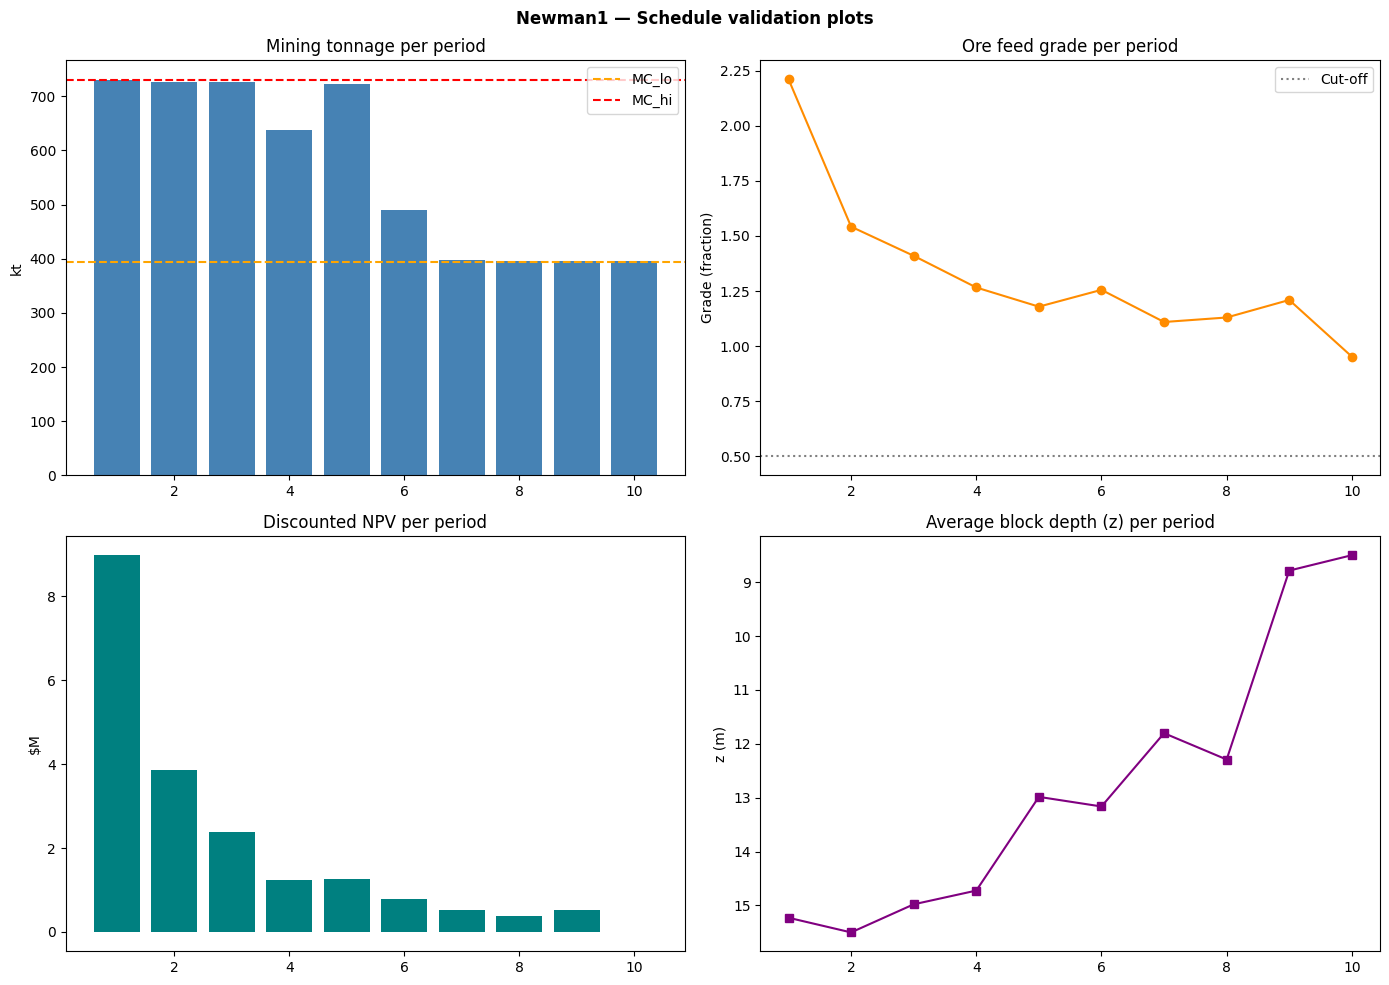

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Period utilisation — should stay within [MC_lo, MC_hi] every period
ax = axes[0, 0]
ax.bar(period_tonnage.index, period_tonnage.values / 1000, color='steelblue')
ax.axhline(MC_lo / 1000, color='orange', linestyle='--', label='MC_lo')
ax.axhline(MC_hi / 1000, color='red',    linestyle='--', label='MC_hi')
ax.set_title('Mining tonnage per period')
ax.set_ylabel('kt'); ax.legend()

# 2. Grade profile — should be relatively stable, not front-loaded then crashing
period_grade = sched_npv.groupby('period').apply(
    lambda g: np.average(g['grade'], weights=g['throughput'])
)
ax = axes[0, 1]
ax.plot(period_grade.index, period_grade.values, 'o-', color='darkorange')
ax.set_title('Ore feed grade per period')
ax.set_ylabel('Grade (fraction)')
ax.axhline(GRADE_CUTOFF, color='gray', linestyle=':', label='Cut-off')
ax.legend()

# 3. Discounted NPV waterfall — most value should come from early periods
period_disc_npv = sched_npv.groupby('period')['disc_npv'].sum()
ax = axes[1, 0]
ax.bar(period_disc_npv.index, period_disc_npv.values, color='teal')
ax.set_title('Discounted NPV per period')
ax.set_ylabel('$M')

# 4. Depth profile — are we mining top-down? (z should generally increase over time)
period_avg_z = sched_npv.merge(
    df_mapped[['block_id','z']], on='block_id'
).groupby('period')['z'].mean()
ax = axes[1, 1]
ax.plot(period_avg_z.index, period_avg_z.values, 's-', color='purple')
ax.set_title('Average block depth (z) per period')
ax.set_ylabel('z (m)')
ax.invert_yaxis()  # deeper = lower z in Newman1

plt.suptitle('Newman1 — Schedule validation plots', fontweight='bold')
plt.tight_layout()
plt.savefig('newman1_validation.png', dpi=150, bbox_inches='tight')
plt.show()